Quick and dirty notebook for simulation of coherent scattering data of magnetic samples in fraunhofer far-field regime

# Import

In [12]:
# Import general libraries
import sys, os
from os.path import join, split
from importlib import reload
from copy import deepcopy
from tqdm.auto import tqdm

import numpy as np

# scipy
import scipy

# plotting
import matplotlib.pyplot as plt

# Interactive plotting
import ipywidgets
%matplotlib widget
plt.rcParams["figure.constrained_layout.use"] = True

In [13]:
# Imports from our own codebase
from scattering_calculator.experimental_conditions import detector, light_beam
from scattering_calculator.sample_generator import pattern_generator, structures
from scattering_calculator.utils import masking
from scattering_calculator.interactive.interactive_widgets import cimshow

### EXPERIMENTAL GEOMETRY

In [14]:
# ===================
# X-ray Source
# ===================
x_ray_energy = 789.9  # eV
x_ray_photon_flux = 1e10  # Photons per pulse
beam_params = light_beam.beam_parameters(
    x_ray_energy, x_ray_photon_flux
)

# ==================
# Geometry
# ==================
detector_pixel_size = 10e-6  # in m
detector_pixel_shape = (2048, 2048)
detector_distance = 0.15  # in m

# Optional: Define a beamstop
beamstop_radius = 0.5e-3  # in m
beamstop_distance = 0.001  # in m
beamstop_center = np.array(detector_pixel_shape) // 2  # in px

# ==================
# Setup
# ==================

# Basic camera parameters
exp_detector = detector.detector_layout(
    pixel_size=detector_pixel_size,
    shape=detector_pixel_shape,
    distance_sample_detector=detector_distance,
)

# Add beamstop to detector layout
beamstop = detector.beamstop(exp_detector, beamstop_distance)
beamstop.create_circle_beamstop(beamstop_center, beamstop_radius,use_real_space_coordinates=True)
bs_mask = beamstop.return_beamstop()
exp_detector.assign_beamstop(bs_mask)

### SAMPLE STACK STRUCTURE AND OPTICAL PROPERTIES

In [15]:

reload(structures)


recipe = "Au(1000)/Co(3)/Pt(2)"
#"Au(1000)/SiN(200)/Ta(5)/[Pt(1)/Co(1)]x15/Pt(3)"

# define stack
stack = structures.parse_recipe(
    recipe,
    sample_name="sample_A",
    comments=["test multilayer"],
)

#pulls material refractive indexes
material_params = structures.material_params(materials=set([element.material for element in stack.layers]), 
                             x_ray_energy=x_ray_energy)


non_magnetic_structure = structures.Structure(
    name="Test Structure",
    material_params=material_params
)

for layer in stack.layers:
    non_magnetic_structure.add_layer(layer.material, thickness=layer.thickness)

eps=np.array(non_magnetic_structure.dielectric_tensors)

print(eps.shape)

(3, 3, 2, 2)


# SAMPLE 

In [17]:
# Basic parameters for the simulation
sample_shape = (len(stack.layers),2**11, 2**11)  # in pixels
real_space_pixel_size = 1e-9  # in m


### - magnetic domains

CPU times: user 2 μs, sys: 1 μs, total: 3 μs
Wall time: 4.05 μs
Placing 150000 skyrmions (fast)...


  0%|          | 0/150000 [00:00<?, ?it/s]

Placed 36 skyrmions in 1000 iterations.


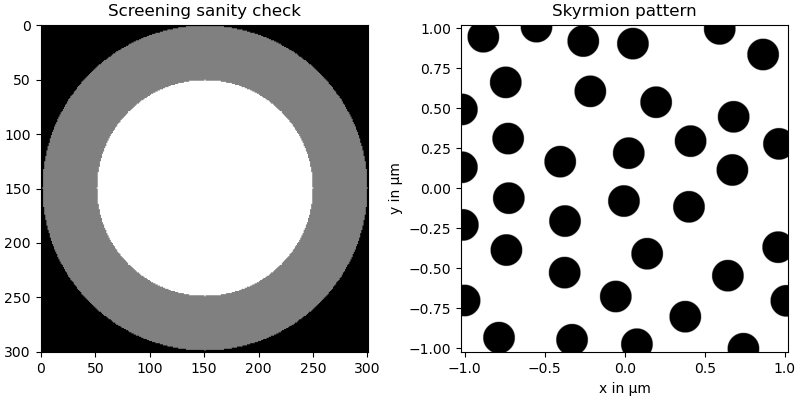

In [18]:

reload(pattern_generator)

%time
# Skyrmion and Screening diameter
skyrmion_radius = 100e-9  # m
screening_radius = (
    1.5 * skyrmion_radius
)  # m, either only even or odd, otherwise script will fail
skyrmion_smoothing = 1

# Number of skyrmions
# If this number is too high, the script may take forever ...
# (brute force algorithm)
number_of_skyrmions = 150000
max_nr_iteration = 1000  # 10 * sample["no_skyr"]

# Create Pattern
skyrmion_pattern, coordinates = pattern_generator.create_skyrmion_pattern(
    sample_shape[1:],
    skyrmion_radius/real_space_pixel_size,
    screening_radius/real_space_pixel_size,
    number_of_skyrmions,
    max_nr_iteration,
    sigma=skyrmion_smoothing,
    real_space_pixel_size = real_space_pixel_size,
    plot=True,
)


In [23]:

M=pattern_generator.map_magnetization_to_3d(skyrmion_pattern,np.sqrt(1-np.abs(skyrmion_pattern)**2),0*skyrmion_pattern,sample_shape,non_magnetic_structure.layer_names,non_magnetic_structure.layer_thicknesses)
M.shape, C.shape

(2048, 2048, 3)
(2048, 2048, 9)


((2048, 2048, 9), (3, 2048, 2048))

# - holography mask

499.9999999999624 2047.0
499.9999999999624 2047.0


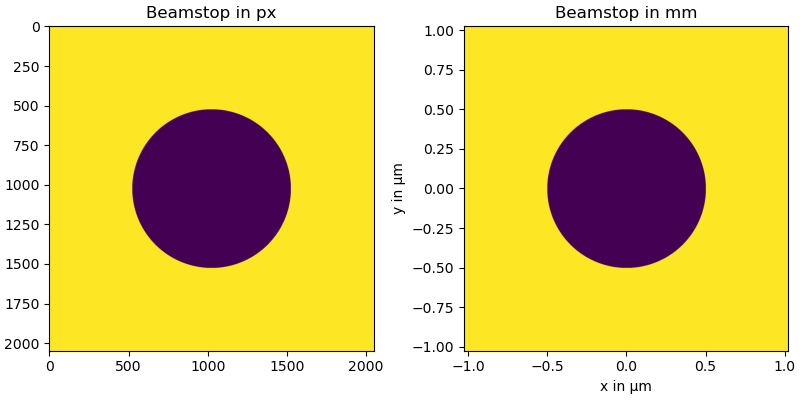

In [24]:
reload(structures)
reload(masking)

front_aperture_radius = 0.5e-6  # in m
front_aperture = structures.Apertures3D(sample_shape, real_space_pixel_size,
    layer_thicknesses=non_magnetic_structure.layer_thicknesses)
front_aperture.create_circle_aperture(
    center=(sample_shape[1] // 2, sample_shape[2] // 2),
    depth=1000e-9,
    radius=front_aperture_radius,
    use_real_space_coordinates=True,
)
front_aperture.visualize_aperture()

C=front_aperture.aperture_design

### ILLUMINATION FUNCTION

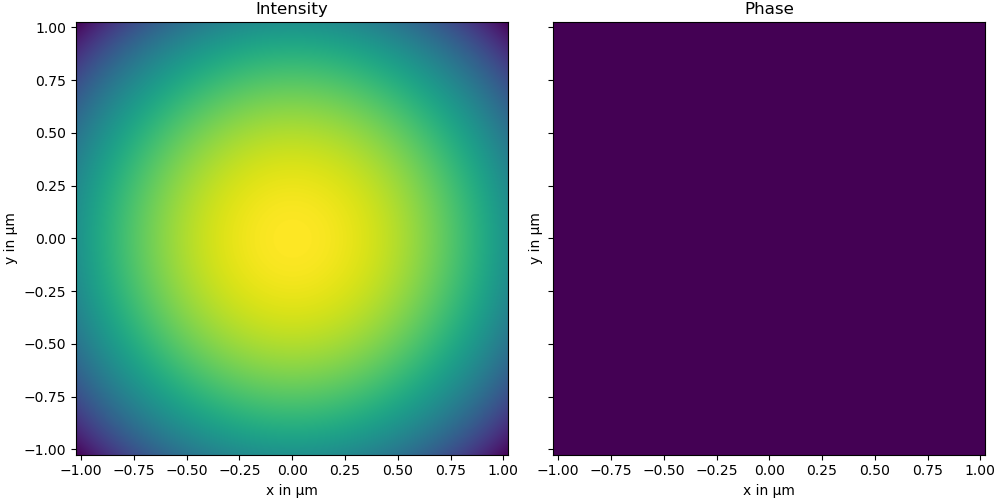

In [25]:
# Params for gaussian beam
illumination_function = "gaussian"
illumination_center = np.array(sample_shape[1:]) // 2  # in px
illumination_focus_distance = 0#in m
illumination_fwhm = 30e-6  # in m

illumination = light_beam.illumination(beam_params, sample_shape[1:], real_space_pixel_size)

# Comment: Check gauss_beam function for different focus distances
illumination.gauss_beam(
    illumination_center,
    illumination_focus_distance,
    illumination_fwhm,
)
illumination_wavefield = illumination.return_illumination()
extent_illumination_real = illumination.get_illumination_extent_real_space()
illumination.visualize_illumination()

### Do light propagation

In [ ]:


eps=np.array(non_magnetic_structure.dielectric_tensors)



T =+np.einsum("zij,zyx->zyxij", eps[:,0,:,:], C)+np.einsum("zij,zyx->zyxij", eps[:,1,:,:], M[:,:,:,2])+np.einsum("zij,zyx->zyxij", eps[:,2,:,:], M[:,:,:,0])-np.einsum("zij,zyx->zyxij", eps[:,2,:,:], M[:,:,:,1])
T =+np.einsum("zyxij,z->zyxij", T,non_magnetic_structure.layer_thicknesses)


## propagation

In [ ]:

eps=np.array(non_magnetic_structure.dielectric_tensors)
T =+np.einsum("zij,zyx->zyxij", eps[:,0,:,:], C)+np.einsum("zij,zyx->zyxij", eps[:,1,:,:], M[:,:,:,2])+np.einsum("zij,zyx->zyxij", eps[:,2,:,:], M[:,:,:,0])-np.einsum("zij,zyx->zyxij", eps[:,2,:,:], M[:,:,:,1])




In [28]:
non_magnetic_structure.layer_thicknesses

[1.0000000000000002e-06, 3.0000000000000004e-09, 2e-09]

In [ ]:
fig,ax=plt.subplots()
ax.imshow(np.abs(T[0,:,:,1,0]))

In [ ]:

def apply_jones_to_wavefield(E_in, J):
    """
    Apply a 2x2 Jones matrix to a coherent 2-component wavefield.

    Parameters
    ----------
    E_in : complex array, shape (2, Ny, Nx)
        Input Jones wavefield.
    J : complex array, shape (2, 2)
        Jones matrix.

    Returns
    -------
    E_out : complex array, shape (2, Ny, Nx)
        Output wavefield.
    """
    E_in = np.asarray(E_in, dtype=complex)
    J = np.asarray(J, dtype=complex)

    if E_in.ndim != 3 or E_in.shape[0] != 2:
        raise ValueError("E_in must have shape (2, Ny, Nx)")
    if J.shape != (2, 2):
        raise ValueError("J must have shape (2, 2)")

    # einsum: output component i = J_ij * E_j
    E_out = np.einsum("ij,jyx->iyx", J, E_in)
    return E_out

In [ ]:
def jones_propagation(eps, wavelength, d):
    k0 = 2 * np.pi / wavelength

    vals, vecs = np.linalg.eig(eps)
    n = np.sqrt(vals)

    P = np.diag(np.exp(1j * k0 * n * d))

    J = vecs @ P @ np.linalg.inv(vecs)
    return J

def propagate_stokes(S_in, M):
    return M @ S_in

def jones_to_mueller(J):
    """
    Convert 2x2 Jones matrix to 4x4 Mueller matrix.
    """
    J = np.asarray(J, dtype=complex)

    # Pauli matrices
    sigma = [
        np.array([[1,0],[0,1]]),
        np.array([[1,0],[0,-1]]),
        np.array([[0,1],[1,0]]),
        np.array([[0,-1j],[1j,0]])
    ]

    M = np.zeros((4,4), dtype=float)

    for i in range(4):
        for j in range(4):
            M[i,j] = 0.5 * np.real(
                np.trace(
                    sigma[i] @ J @ sigma[j] @ J.conj().T
                )
            )
    return M



wavelength = 1.6e-9
d = 1.59e-9


# Step 1: input (partially polarized)
S_in = np.array([1, 0, 0, 1])


# Step 2: Jones
J = jones_propagation(np.sum(eps_tot, axis=0), wavelength, d)
# Step 3: Mueller
M = jones_to_mueller(J)
# Step 4: propagate
S_out = propagate_stokes(S_in, M)

print("Output Stokes:", S_out)


In [ ]:
eps_tot



In [ ]:
import numpy as np
from dataclasses import dataclass

# ============================================================
# Basic optics helpers
# ============================================================


def intensity_from_jones(E):
    E = np.asarray(E, dtype=complex)
    return float(np.vdot(E, E).real)


def normalize_jones(E):
    E = np.asarray(E, dtype=complex)
    I = intensity_from_jones(E)
    if I == 0:
        return E
    return E / np.sqrt(I)


def stokes_from_jones(E):
    """
    Stokes vector from Jones vector in the linear (x,y) basis.

    Returns:
        S = [S0, S1, S2, S3]
    where:
        S0 = total intensity
        S1 = H - V
        S2 = +45 - -45
        S3 = R - L
    """
    Ex, Ey = np.asarray(E, dtype=complex)

    S0 = (np.abs(Ex)**2 + np.abs(Ey)**2).real
    S1 = (np.abs(Ex)**2 - np.abs(Ey)**2).real
    S2 = (2.0 * np.real(Ex * np.conj(Ey))).real
    S3 = (-2.0 * np.imag(Ex * np.conj(Ey))).real
    return np.array([S0, S1, S2, S3], dtype=float)


def describe_field(E, name="field"):
    E = np.asarray(E, dtype=complex)
    S = stokes_from_jones(E)
    print(f"--- {name} ---")
    print("Jones vector:")
    print(E)
    print(f"Intensity = {intensity_from_jones(E):.6e}")
    print("Stokes =")
    print(S)
    if S[0] > 0:
        print("Normalized Stokes =")
        print(S / S[0])
    print()


# ============================================================
# Input polarization states
# ============================================================

def pol_elliptical(amp_x, amp_y, phase_y_minus_x):
    """
    General mixed / elliptical input polarization in linear basis:
        E = [amp_x, amp_y * exp(i phase)]
        (+1,+0,+0)    = LH
        (+0,+1,+0)    = LV
        (+1,+1,+0)    = +45 linear
        (+1,-1,+0)    = -45 linear
        (+1,+1,+pi/2) = CR
        (+1,+1,-pi/2) = CL
    """
    return np.array([amp_x, amp_y * np.exp(1.0j * phase_y_minus_x)], dtype=complex)

def pol_from_stokes(S):
    """
    Construct one Jones vector consistent with a fully polarized Stokes vector.
    Assumes S corresponds to a fully polarized state:
        S0^2 = S1^2 + S2^2 + S3^2
    """
    S = np.asarray(S, dtype=float)
    S0, S1, S2, S3 = S

    if S0 <= 0:
        raise ValueError("S0 must be positive.")

    # normalized Stokes
    s1, s2, s3 = S1 / S0, S2 / S0, S3 / S0

    # choose Ex real and nonnegative
    Ex2 = max((1 + s1) / 2, 0.0)
    Ey2 = max((1 - s1) / 2, 0.0)
    Ex = np.sqrt(Ex2)
    Ey = np.sqrt(Ey2)

    # relative phase from s2, s3
    if Ex * Ey > 0:
        phi = np.arctan2(-s3, s2)
    else:
        phi = 0.0

    E = np.array([Ex, Ey * np.exp(1.0j * phi)], dtype=complex)
    return np.sqrt(S0) * normalize_jones(E)



# ============================================================
# Propagation through one homogeneous slice
# ============================================================

@dataclass
class PropagationResult:
    eps_tensor: np.ndarray
    eps_eigvals: np.ndarray
    eigvecs: np.ndarray
    n_modes: np.ndarray
    jones_matrix: np.ndarray
    E_in: np.ndarray
    E_out: np.ndarray
    S_in: np.ndarray
    S_out: np.ndarray
    I_in: float
    I_out: float


def propagate_slice(E_in, wavelength, thickness, eps_tensor):
    """
    Propagate Jones field through one homogeneous slice at normal incidence.

    Parameters
    ----------
    E_in : array-like shape (2,)
        Input Jones vector in linear basis.
    wavelength : float
        Vacuum wavelength [m]
    thickness : float
        Thickness [m]
    eps_tensor : 2x2 complex array
        Transverse dielectric tensor in linear basis.

    Returns
    -------
    PropagationResult
    """
    E_in = np.asarray(E_in, dtype=complex)
    eps_tensor = np.asarray(eps_tensor, dtype=complex)

    # Diagonalize dielectric tensor
    eigvals, eigvecs = np.linalg.eig(eps_tensor)

    # Refractive indices of eigenmodes
    n_modes = np.sqrt(eigvals)

    k0 = 2.0 * np.pi / wavelength
    phases = np.exp(1.0j * k0 * n_modes * thickness)

    J = eigvecs @ np.diag(phases) @ np.linalg.inv(eigvecs)
    E_out = J @ E_in

    S_in = stokes_from_jones(E_in)
    S_out = stokes_from_jones(E_out)

    return PropagationResult(
        eps_tensor=eps_tensor,
        eps_eigvals=eigvals,
        eigvecs=eigvecs,
        n_modes=n_modes,
        jones_matrix=J,
        E_in=E_in,
        E_out=E_out,
        S_in=S_in,
        S_out=S_out,
        I_in=float(S_in[0]),
        I_out=float(S_out[0]),
    )


# ============================================================
# High-level convenience wrapper
# ============================================================

def propagate_from_indices(
    wavelength,
    thickness,
    n0,
    dn_lin=0.0+0.0j,
    dn_circ=0.0+0.0j,
    theta=0.0,
    E_in=None
):
    """
    Build dielectric tensor from n0, dn_lin, dn_circ, theta
    and propagate the input field through the slice.
    """
    if E_in is None:
        E_in = pol_linear_x()

    eps = dielectric_tensor_mixed(n0=n0, dn_lin=dn_lin, dn_circ=dn_circ, theta=theta)
    return propagate_slice(E_in=E_in, wavelength=wavelength, thickness=thickness, eps_tensor=eps)


# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    # --------------------------------------------------------
    # Example material parameters
    # --------------------------------------------------------
    wavelength = 1.59e-9   # ~780 eV
    d = 1.0e-9             # 1 nm slice

    # Baseline isotropic refractive index
    delta0 = 3.5e-3
    beta0 = 5.0e-3
    n0 = n_from_delta_beta(delta0, beta0)

    # Small linear anisotropy contribution
    # example: x and y differ slightly
    dn_lin = (1.0e-4 + 0.5e-4j)

    # Small circular anisotropy contribution
    # example: XMCD-like splitting
    dn_circ = (0.8e-4 + 0.6e-4j)

    # Rotate linear anisotropy axes by 20 degrees
    theta = np.deg2rad(20.0)

    # --------------------------------------------------------
    # Example 1: horizontal linear input
    # --------------------------------------------------------
    E_H = normalize_jones(pol_linear_x())
    res_H = propagate_from_indices(
        wavelength=wavelength,
        thickness=d,
        n0=n0,
        dn_lin=dn_lin,
        dn_circ=dn_circ,
        theta=theta,
        E_in=E_H
    )

    print("=== Example: horizontal linear input ===")
    print("Dielectric tensor:")
    print(res_H.eps_tensor)
    print("Eigenmode refractive indices:")
    print(res_H.n_modes)
    print("Jones matrix:")
    print(res_H.jones_matrix)
    describe_field(res_H.E_in, "Input H")
    describe_field(res_H.E_out, "Output H")

    # --------------------------------------------------------
    # Example 2: right circular input
    # --------------------------------------------------------
    E_R = normalize_jones(pol_right_circular())
    res_R = propagate_from_indices(
        wavelength=wavelength,
        thickness=d,
        n0=n0,
        dn_lin=dn_lin,
        dn_circ=dn_circ,
        theta=theta,
        E_in=E_R
    )

    print("=== Example: right circular input ===")
    describe_field(res_R.E_in, "Input R")
    describe_field(res_R.E_out, "Output R")

    # --------------------------------------------------------
    # Example 3: arbitrary mixed / elliptical input
    # --------------------------------------------------------
    E_mix = normalize_jones(pol_elliptical(
        amp_x=1.0,
        amp_y=0.7,
        phase_y_minus_x=np.pi/3
    ))

    res_mix = propagate_from_indices(
        wavelength=wavelength,
        thickness=d,
        n0=n0,
        dn_lin=dn_lin,
        dn_circ=dn_circ,
        theta=theta,
        E_in=E_mix
    )

    print("=== Example: mixed elliptical input ===")
    describe_field(res_mix.E_in, "Input mixed")
    describe_field(res_mix.E_out, "Output mixed")

In [ ]:
reload(structures)
fig,(ax,ax3,ax2)=plt.subplots(3,1)

for E in np.arange(760,820,1):

    #n=structures.material_params.get_refractive_index(material_name="Co", energy=E)
    #print(n)
    n=structures.material_params.load_refractive_index(material_name="Co", energy=E)
    ax.scatter(E,np.real(n[0]), c="k")
    ax3.scatter(E,np.imag(n[0]), c="r")

    ax2.scatter(E,np.real(n[1]), c="k")
    ax2.scatter(E,np.imag(n[1]), c="r")


In [ ]:
import numpy as np
from dataclasses import dataclass

# ============================================================
# Basic optics helpers
# ============================================================

def n_from_delta_beta(delta, beta):
    """
    Refractive index from delta, beta using convention:
        n = 1 - delta - i beta
    """
    return 1.0 - delta - 1.0j * beta


def intensity_from_jones(E):
    E = np.asarray(E, dtype=complex)
    return float(np.vdot(E, E).real)


def normalize_jones(E):
    E = np.asarray(E, dtype=complex)
    I = intensity_from_jones(E)
    if I == 0:
        return E
    return E / np.sqrt(I)


def stokes_from_jones(E):
    """
    Stokes vector from Jones vector in the linear (x,y) basis.

    Returns:
        S = [S0, S1, S2, S3]
    where:
        S0 = total intensity
        S1 = H - V
        S2 = +45 - -45
        S3 = R - L
    """
    Ex, Ey = np.asarray(E, dtype=complex)

    S0 = (np.abs(Ex)**2 + np.abs(Ey)**2).real
    S1 = (np.abs(Ex)**2 - np.abs(Ey)**2).real
    S2 = (2.0 * np.real(Ex * np.conj(Ey))).real
    S3 = (-2.0 * np.imag(Ex * np.conj(Ey))).real
    return np.array([S0, S1, S2, S3], dtype=float)


def describe_field(E, name="field"):
    E = np.asarray(E, dtype=complex)
    S = stokes_from_jones(E)
    print(f"--- {name} ---")
    print("Jones vector:")
    print(E)
    print(f"Intensity = {intensity_from_jones(E):.6e}")
    print("Stokes =")
    print(S)
    if S[0] > 0:
        print("Normalized Stokes =")
        print(S / S[0])
    print()


# ============================================================
# Input polarization states
# ============================================================

def pol_linear_x(amplitude=1.0):
    return np.array([amplitude, 0.0], dtype=complex)

def pol_linear_y(amplitude=1.0):
    return np.array([0.0, amplitude], dtype=complex)

def pol_linear_angle(theta_rad, amplitude=1.0):
    return amplitude * np.array([np.cos(theta_rad), np.sin(theta_rad)], dtype=complex)

def pol_right_circular(amplitude=1.0):
    return amplitude * np.array([1.0, 1.0j], dtype=complex) / np.sqrt(2)

def pol_left_circular(amplitude=1.0):
    return amplitude * np.array([1.0, -1.0j], dtype=complex) / np.sqrt(2)

def pol_elliptical(amp_x, amp_y, phase_y_minus_x):
    """
    General mixed / elliptical input polarization in linear basis:
        E = [amp_x, amp_y * exp(i phase)]
    """
    return np.array([amp_x, amp_y * np.exp(1.0j * phase_y_minus_x)], dtype=complex)

def pol_from_stokes(S):
    """
    Construct one Jones vector consistent with a fully polarized Stokes vector.
    Assumes S corresponds to a fully polarized state:
        S0^2 = S1^2 + S2^2 + S3^2
    """
    S = np.asarray(S, dtype=float)
    S0, S1, S2, S3 = S

    if S0 <= 0:
        raise ValueError("S0 must be positive.")

    # normalized Stokes
    s1, s2, s3 = S1 / S0, S2 / S0, S3 / S0

    # choose Ex real and nonnegative
    Ex2 = max((1 + s1) / 2, 0.0)
    Ey2 = max((1 - s1) / 2, 0.0)
    Ex = np.sqrt(Ex2)
    Ey = np.sqrt(Ey2)

    # relative phase from s2, s3
    if Ex * Ey > 0:
        phi = np.arctan2(-s3, s2)
    else:
        phi = 0.0

    E = np.array([Ex, Ey * np.exp(1.0j * phi)], dtype=complex)
    return np.sqrt(S0) * normalize_jones(E)



# ============================================================
# Propagation through one homogeneous slice
# ============================================================

@dataclass
class PropagationResult:
    eps_tensor: np.ndarray
    eps_eigvals: np.ndarray
    eigvecs: np.ndarray
    n_modes: np.ndarray
    jones_matrix: np.ndarray
    E_in: np.ndarray
    E_out: np.ndarray
    S_in: np.ndarray
    S_out: np.ndarray
    I_in: float
    I_out: float


def propagate_slice(E_in, wavelength, thickness, eps_tensor):
    """
    Propagate Jones field through one homogeneous slice at normal incidence.

    Parameters
    ----------
    E_in : array-like shape (2,)
        Input Jones vector in linear basis.
    wavelength : float
        Vacuum wavelength [m]
    thickness : float
        Thickness [m]
    eps_tensor : 2x2 complex array
        Transverse dielectric tensor in linear basis.

    Returns
    -------
    PropagationResult
    """
    E_in = np.asarray(E_in, dtype=complex)
    eps_tensor = np.asarray(eps_tensor, dtype=complex)

    # Diagonalize dielectric tensor
    eigvals, eigvecs = np.linalg.eig(eps_tensor)

    # Refractive indices of eigenmodes
    n_modes = np.sqrt(eigvals)

    k0 = 2.0 * np.pi / wavelength
    phases = np.exp(1.0j * k0 * n_modes * thickness)

    J = eigvecs @ np.diag(phases) @ np.linalg.inv(eigvecs)
    E_out = J @ E_in

    S_in = stokes_from_jones(E_in)
    S_out = stokes_from_jones(E_out)

    return PropagationResult(
        eps_tensor=eps_tensor,
        eps_eigvals=eigvals,
        eigvecs=eigvecs,
        n_modes=n_modes,
        jones_matrix=J,
        E_in=E_in,
        E_out=E_out,
        S_in=S_in,
        S_out=S_out,
        I_in=float(S_in[0]),
        I_out=float(S_out[0]),
    )


# ============================================================
# High-level convenience wrapper
# ============================================================

def propagate_from_indices(
    wavelength,
    thickness,
    n0,
    dn_lin=0.0+0.0j,
    dn_circ=0.0+0.0j,
    theta=0.0,
    E_in=None
):
    """
    Build dielectric tensor from n0, dn_lin, dn_circ, theta
    and propagate the input field through the slice.
    """
    if E_in is None:
        E_in = pol_linear_x()

    eps = dielectric_tensor_mixed(n0=n0, dn_lin=dn_lin, dn_circ=dn_circ, theta=theta)
    return propagate_slice(E_in=E_in, wavelength=wavelength, thickness=thickness, eps_tensor=eps)


# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    # --------------------------------------------------------
    # Example material parameters
    # --------------------------------------------------------
    wavelength = 1.59e-9   # ~780 eV
    d = 1.0e-9             # 1 nm slice

    # Baseline isotropic refractive index
    delta0 = 3.5e-3
    beta0 = 5.0e-3
    n0 = n_from_delta_beta(delta0, beta0)

    # Small linear anisotropy contribution
    # example: x and y differ slightly
    dn_lin = (1.0e-4 + 0.5e-4j)

    # Small circular anisotropy contribution
    # example: XMCD-like splitting
    dn_circ = (0.8e-4 + 0.6e-4j)

    # Rotate linear anisotropy axes by 20 degrees
    theta = np.deg2rad(20.0)

    # --------------------------------------------------------
    # Example 1: horizontal linear input
    # --------------------------------------------------------
    E_H = normalize_jones(pol_linear_x())
    res_H = propagate_from_indices(
        wavelength=wavelength,
        thickness=d,
        n0=n0,
        dn_lin=dn_lin,
        dn_circ=dn_circ,
        theta=theta,
        E_in=E_H
    )

    print("=== Example: horizontal linear input ===")
    print("Dielectric tensor:")
    print(res_H.eps_tensor)
    print("Eigenmode refractive indices:")
    print(res_H.n_modes)
    print("Jones matrix:")
    print(res_H.jones_matrix)
    describe_field(res_H.E_in, "Input H")
    describe_field(res_H.E_out, "Output H")

    # --------------------------------------------------------
    # Example 2: right circular input
    # --------------------------------------------------------
    E_R = normalize_jones(pol_right_circular())
    res_R = propagate_from_indices(
        wavelength=wavelength,
        thickness=d,
        n0=n0,
        dn_lin=dn_lin,
        dn_circ=dn_circ,
        theta=theta,
        E_in=E_R
    )

    print("=== Example: right circular input ===")
    describe_field(res_R.E_in, "Input R")
    describe_field(res_R.E_out, "Output R")

    # --------------------------------------------------------
    # Example 3: arbitrary mixed / elliptical input
    # --------------------------------------------------------
    E_mix = normalize_jones(pol_elliptical(
        amp_x=1.0,
        amp_y=0.7,
        phase_y_minus_x=np.pi/3
    ))

    res_mix = propagate_from_indices(
        wavelength=wavelength,
        thickness=d,
        n0=n0,
        dn_lin=dn_lin,
        dn_circ=dn_circ,
        theta=theta,
        E_in=E_mix
    )

    print("=== Example: mixed elliptical input ===")
    describe_field(res_mix.E_in, "Input mixed")
    describe_field(res_mix.E_out, "Output mixed")

In [ ]:
import numpy as np

def jones_from_dielectric(eps, wavelength, thickness):
    """
    eps: 2x2 complex dielectric tensor (transverse)
    """
    k0 = 2 * np.pi / wavelength

    # eigen-decomposition
    vals, vecs = np.linalg.eig(eps)

    # refractive indices
    n = np.sqrt(vals)

    # propagation
    D = np.diag(np.exp(1j * k0 * n * thickness))

    # Jones matrix
    J = vecs @ D @ np.linalg.inv(vecs)
    return J


eps_d = (1 - 3.5e-3) + 1j*(5e-3)
eps_m = 5e-4 + 1j*(1e-4)

eps = np.array([
    [eps_d, 1j*eps_m],
    [-1j*eps_m, eps_d]
])

J = jones_from_dielectric(eps, wavelength=1.59e-9, thickness=1e-9)


print(J)

In [ ]:
magnetic_structure = structures.Structure(
    name="Test Structure", material_params=material_params
)
magnetic_structure.add_layer("Co", thickness=2e-9)
for i in range(15):
    magnetic_structure.add_layer("Co", thickness=1e-9)

magnetic_structure.visualize_structure()
magnetic_structure.return_total_effective_refractive_index()

## Magnetic pattern

In [ ]:
reload(pattern_generator)

%time
# Skyrmion and Screening diameter
skyrmion_radius = 1e-6  # m
screening_radius = (
    1.5 * skyrmion_radius
)  # m, either only even or odd, otherwise script will fail
skyrmion_smoothing = 1

# Number of skyrmions
# If this number is too high, the script may take forever ...
# (brute force algorithm)
number_of_skyrmions = 150000
max_nr_iteration = 300000  # 10 * sample["no_skyr"]

# Create Pattern
skyrmion_pattern, coordinates = pattern_generator.create_skyrmion_pattern(
    sample_shape,
    skyrmion_radius / real_space_pixel_size,
    screening_radius / real_space_pixel_size,
    number_of_skyrmions,
    max_nr_iteration,
    sigma=skyrmion_smoothing,
    real_space_pixel_size = real_space_pixel_size,
    plot=True,
)


# Define parameter
lattice_constant = (1e-6,
                    1e-6)  # in m

# Random shift of lattice points (either value as gaussian fwhm or 'none')
lattice_shift = 0.025e-6  # in m

# Occupy all lattice points with skyrmions?
lattice_filling = 1  # ranging from [0,1] 

sample_shape=(100,100)
# Create lattice
lattice = pattern_generator.create_lattice(sample_shape,real_space_pixel_size, lattice_constant, lattice_filling, lattice_shift, plot=True)

In [ ]:
# Skyrmion diameter and diameter spread derived from gaussian
skyrmion_radius = .3e-6  # m["dia_spread_fwhm"] = 0.03e-6  # full width at half maximum gaussian or 'none'
skyrmion_smoothing = 0.5
skyrmion_diameter_spread_fwhm = 0.03e-6

# Put Skyrmions on lattice points
pattern = pattern_generator.skyrmions_on_lattice(
    sample_shape,
    lattice,
    skyrmion_radius / real_space_pixel_size,
    skyrmion_smoothing,
    skyrmion_diameter_spread_fwhm,
    real_space_pixel_size=real_space_pixel_size,
    plot=True,
)